# Mô phỏng chỉ số VN30

Notebook này thực hiện việc lọc các mã cổ phiếu thuộc rổ VN30 và tính toán biến động luỹ kế dựa trên phương pháp trọng số đều (Equal-Weight) để mô phỏng biểu đồ của VN30. Do không có sẵn dữ liệu khối lượng lưu hành (shares outstanding) để tính vốn hoá thị trường chính xác, phương pháp Equal-Weight (trung bình đều) cung cấp một mô phỏng tương đối và trực quan đánh giá nhóm VN30.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

In [26]:
# 1. Đọc danh sách mã VN30
with open('../market_lists/vn100.txt', 'r') as f:
    vn100_tickers = [line.strip() for line in f.readlines() if line.strip()]

print(f"Số lượng mã VN100 tải được: {len(vn100_tickers)}")
print("Danh sách:", vn100_tickers)

Số lượng mã VN100 tải được: 100
Danh sách: ['ACB', 'ANV', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEE', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNM', 'VPB', 'VPI', 'VRE', 'VSC', 'VTP']


In [27]:
# 2. Tải dữ liệu lịch sử và lọc VN30
data_path = '../data/processed/assets/data_info_vn/history/vn_gold_recommended.csv'
cols = ['Date', 'code', 'intraday_return', 'adjust']
df = pd.read_csv(data_path, usecols=cols)
# df = pd.read_csv(data_path)
# print(df.columns)


# Chuyển Date sang chuẩn datetime
df['Date'] = pd.to_datetime(df['Date'])

# Lọc các mã trong rổ VN100
vn100_df = df[df['code'].isin(vn100_tickers)].copy()
vn100_df.dropna(subset=['intraday_return'], inplace=True)
print("Dữ liệu VN100 tải về thành công, kích thước:", vn100_df.shape)
print(vn100_df.head())



Dữ liệu VN100 tải về thành công, kích thước: (277096, 4)
        Date code       adjust  intraday_return
0 2012-03-20  ACB  4194.301758         0.005780
1 2012-03-21  ACB  4210.622559         0.005747
2 2012-03-22  ACB  4210.622559        -0.008499
3 2012-03-23  ACB  4177.981934         0.000000
4 2012-03-26  ACB  4210.622559        -0.011299


In [28]:
# 3. Tính toán Index Mô phỏng (Equal-Weight)
# Tính trung bình tỷ suất sinh lời của rổ VN30 trong mỗi ngày
vn100_daily = vn100_df.groupby('Date').agg(
    daily_return=('intraday_return', 'mean'),
    stock_count=('code', 'count')
).reset_index()

# Tính lợi nhuận luỹ kế (Cumulative Return)
# Giả định điểm bắt đầu là giá trị 1000
vn100_daily['cum_return'] = (1 + vn100_daily['daily_return']).cumprod()
vn100_daily['simulated_index'] = 1000 * vn100_daily['cum_return']

vn100_daily.set_index('Date', inplace=True)
display(vn100_daily.head())

,daily_return,stock_count,cum_return,simulated_index
Date,,,,
2012-03-19,0.023810,1,1.023810,1023.809524
2012-03-20,0.011309,54,1.035388,1035.388176
2012-03-21,0.007119,52,1.042759,1042.758919
2012-03-22,0.009204,53,1.052356,1052.356130
2012-03-23,0.003675,53,1.056224,1056.223754


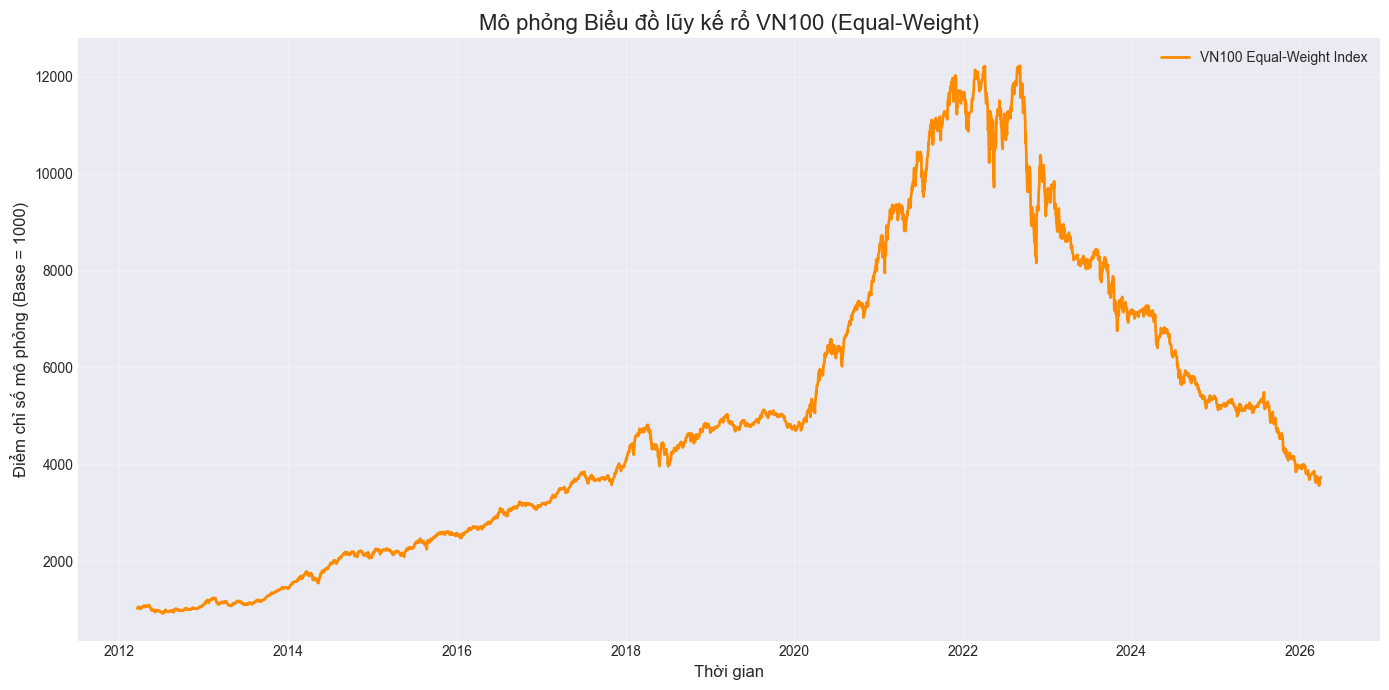

In [29]:
# 4. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
plt.plot(vn100_daily.index, vn100_daily['simulated_index'], label='VN100 Equal-Weight Index', color='darkorange', linewidth=2)
plt.title('Mô phỏng Biểu đồ lũy kế rổ VN100 (Equal-Weight)', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Điểm chỉ số mô phỏng (Base = 1000)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()